In [75]:
import os
os.getcwd()

'C:\\Users\\marcelo'

In [ ]:
import os
os.listdir()

EXEMPLO 1 - IDADES

Abaixo iremos criar um dataframe que contem uma coluna de idades, propositalmente colocaremos dados que indicam problem de 
digitação no preenchiment, acreditem acontece muito.

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [78]:
# Criando um DataFrame com algumas idades para exemplo

dados = {'Idade' : [25, 30, 35, 400, 45, 50, 554, 60, 60, 24, 233, 70, 26]}
df = pd.DataFrame(dados)
print(df)

    Idade
0      25
1      30
2      35
3     400
4      45
5      50
6     554
7      60
8      60
9      24
10    233
11     70
12     26


Imaginem que podulamos a etapa de pré processamento dos dados e fomos diretamente para a análisde explanatória trazendo 
a média das idades:

In [79]:
df['Idade'].mean()

np.float64(124.0)

Agora imagine voc^apresentar para o gestor que pediu a análise que a média da idade dos clientes é de 124 anos, eles logo irão
questionar pela falta de atenção, poi tem algo errado com esse número!

EXEMPLO 2 - CIDADES
Outros porblemas que costumam ser frequentes na qualidade dos dados:

- Acentuação
- Errors de Digitação
- Letras Maíusculas e Minúsculas
  

In [80]:
dados = {"Idade": [25, 30, 35, 400, 45, 50, 554, 60, 60, 24, 233, 70, 26],
         'Cidade': ['São Paulo', 'Salvador', 'Curitiba', 'Sao paulo', 'Salvador', 'Curitiba','Sao Paulo', 'Salvador','salvador','Curitiba','São Paulo','São Paulo','salvaor']
        }
df = pd.DataFrame(dados)
print(df)

    Idade     Cidade
0      25  São Paulo
1      30   Salvador
2      35   Curitiba
3     400  Sao paulo
4      45   Salvador
5      50   Curitiba
6     554  Sao Paulo
7      60   Salvador
8      60   salvador
9      24   Curitiba
10    233  São Paulo
11     70  São Paulo
12     26    salvaor


Vamos trazer a média das idades por cidade realizando um agrupamento por cidade como vimos no módulo de estatística básica.

In [81]:
df.groupby('Cidade')['Idade'].mean().round(2).reset_index(name='Media_Idade')

,Cidade,Media_Idade
0,Curitiba,36.33
1,Salvador,45.00
2,Sao Paulo,554.00
3,Sao paulo,400.00
4,São Paulo,109.33
5,salvador,60.00
6,salvaor,26.00


Notamo que neste exemplo as cidades que deveriam estar agrupadas acabam se repetindo
- Salvador contém um erro de digitação
- São Paulo aparece com e sem acentuação
- Salvador também aparece com a primeira letra minúscula
Se não realizarmos o tratamento desses dados dificilmente chegaremos a média correta das idades por cidade.

EXEMPLO 3 - SALÁRIO
Mitas vezes também acabamos lidando com valores aisentes nas nossas bases de dados. Isso acontece pois muitos clientes acabam não fornecendo todos seus dados ou até por conta de falhas na coleta dos dados.

In [82]:
dados = {
    'Idade': [25, 30, 35, 400, 45, 50, 554, 60, 60, 24, 233, 70, 26],
    'Cidade': ['São Paulo', 'Salvador', 'Curitiba', 'Sao Paulo','Salvador','Curitiba','Sao Paulo', 'Salvador','salvador', 'Curitiba','São Paulo','São Paulo','salvador'],
    'Salario':['1200,0','0','4000,0','0','5000,0','1500,0','0','0','0','3000,0','2500,0','3000,0','0']
}

df = pd.DataFrame(dados)
print(df)

    Idade     Cidade Salario
0      25  São Paulo  1200,0
1      30   Salvador       0
2      35   Curitiba  4000,0
3     400  Sao Paulo       0
4      45   Salvador  5000,0
5      50   Curitiba  1500,0
6     554  Sao Paulo       0
7      60   Salvador       0
8      60   salvador       0
9      24   Curitiba  3000,0
10    233  São Paulo  2500,0
11     70  São Paulo  3000,0
12     26   salvador       0


Vejam que no dataframe acima algumas linhas estáo sem o preenchimento dos dados de salário, retornando 0. Em uma primeira olhada podemos até pensar que por ter outras linhas preenschidas os valores podem não afetar a análise.
Mas notemos que a ciade de salvador não tem 1  linha se quer preenchda com o campo salário.Vocês já sabem que ops modelos de machine learning de aprendizado supervisionado utilizam dados históricos para aprender com esses dados. Imaginem que nosso modelo tivesse a proposta de prever exatamente o salário apenas analisando a idade e cidade. Bem, se nosso modelo não tiver exemplos para a cidade de Salvador isso pode enviezar seus resultados sempre que essa cidade aparecer. Nosso modelo trará uma conclusão distorcidad de que sempre nessa cidade o salário será 0.

Outro fator é que quanto mais dados ausentes, masi dificultosa a aprendizagem do modelo. O modelo precisa do máximo de informaçao.


Usando esse mesmo exemplo da coluna salário iremos demonstrar outro fator crucial que influência no tratamento dos dados.

In [84]:
df['Salario'].mean()

TypeError: Could not convert string '1200,004000,005000,01500,00003000,02500,03000,00' to numeric

Vejam qu por conta da vírgula, ele entende essa coluna como sendo string e não numérica e por isso não consegue aplicar nenhuma função matemática.
É crucial que nós analisemos os tipos de daos antes de iniciar qualquer análise ou modelo.

**MÓDULO 14 - AULA 2**

**Verificando e tratando tipos de Dados**

O primeio problema qeu lidamos na aula poassada e qe encinarei para você é o tratamento dos tipos de dados do nosso dataframe.

Antes de avançarmos vamos ver **a primeira base que trabalharemos** neste curso, nossa **base de análise de crédito**. A proposta dela é que após aplicarmos todas nossas etapas de processamento de dados, apliquemos nosso primeirop modelo de machine learning nela.
Tentando identificar quias são os **clientes popensos ao churn**.

**CHURN** é um termo utilizado e empresa para descrever a taxa de perda ou cancelamento de clientes ao longo do tempo 

In [85]:
df = pd.read_csv("C:\\Users\\marcelo\\CHURN_CREDIT_MOD14.csv", delimiter=';')

df.head(10)

C:\Users\marcelo\AppData\Local\Temp\ipykernel_40332\3951787358.py:1: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:\\Users\\marcelo\\CHURN_CREDIT_MOD14.csv", delimiter=';')


,CustomerId,Sobrenome,Credit_Score,Pais,Genero,Idade,Tempo_Credito,Balance,Qtd_Produtos,Possui_Cartao,Membro_Ativo,Salario_Anual,Churn
0,15813451,Fleetwood-Smith,677,Spain,Male,18.0,5,134796.87,2,1.0,0.0,114858.9,0.0
1,15641688,Collier,644,Spain,Female,18.0,7,0.00,1,0.0,1.0,74564.41,0.0
2,15757821,Burgess,641,Spain,Male,18.0,1,0.00,2,0.0,1.0,41542.95,0.0
3,15673180,Onyekaozulu,826,Spain,Male,18.0,2,0.00,2,0.0,1.0,16245.25,0.0
4,15664543,Tuan,774,Spain,Female,18.0,1,185891.54,1,1.0,0.0,175072.41,0.0
5,15673180,Onyekaozulu,688,Spain,Female,18.0,2,0.00,2,1.0,0.0,98349.13,0.0
6,15641688,Collier,803,Spain,Male,18.0,6,0.00,1,0.0,0.0,59645.24,1.0
7,15672940,Yevseyev,578,Spain,Female,18.0,8,71843.15,2,0.0,1.0,112649.22,0.0
8,15694192,Nwankwo,598,Spain,Male,18.0,6,0.00,2,0.0,1.0,173783.38,0.0
9,15585867,Iroawuchi,624,Spain,Female,18.0,6,0.00,2,0.0,1.0,117038.96,0.0


Notem que logo de cara já recbemos um aviso na tela. Sempre que temos warnings acima do retorno do nossos códigos precisamos nos atender e tomar cuidado. Nesse caso ele indica
que algumas colunas contém mais de 1 tipo de dados, o que pode afetar o processamento.

**Interpretando e Entendendo cada campo da tabela**
**CustomertID**:Esse é o ID unico de cada cliente nosso
**Sobrenome** Sobrenome de cada cliente
**Credit_)Score**: É o Score de crédito de cada cliente, muito semelhante aquele número que o serasa e outras empresas atribuemn pra os clientes.
**Pais**: O pais de cada cliente
**iDADE**: A idade de cada cliente
**Tempo_Credito**: Há quanto tempo nosso cliente utiliza produtos de crédito na nossa empresa - ANOS-.
**Balance**: É o balanço final do nosso cliente, o quanto ele tem em aberto conosco para ainda pagar.
**Qtde_Produtos**: Quantos produtos ele tem contratado com a gente.
**Possui_Cartao**: Se ele possui cartão de crédito.
**Membro_Ativo**: Se atualmente ele é um membro ativo na nosssa empresa.
**Salario_anual**: Salário anual do nosso cliente em dólares por ano.
**Churn**: Se nosso cliente deu churn, **1 para clientes que nos abandonaram e 0 para cliente sque ainda estão conosco!**

In [86]:
# Comando pra verificar qual o tipo de dado de cada coluna.
df.dtypes

CustomerId         int64
Sobrenome         object
Credit_Score       int64
Pais              object
Genero            object
Idade            float64
Tempo_Credito      int64
Balance          float64
Qtd_Produtos       int64
Possui_Cartao    float64
Membro_Ativo     float64
Salario_Anual     object
Churn            float64
dtype: object

In [87]:
#Comando para mostrar um resumo técnico completo do DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   CustomerId     100000 non-null  int64  
 1   Sobrenome      100000 non-null  object 
 2   Credit_Score   100000 non-null  int64  
 3   Pais           100000 non-null  object 
 4   Genero         99990 non-null   object 
 5   Idade          99794 non-null   float64
 6   Tempo_Credito  100000 non-null  int64  
 7   Balance        100000 non-null  float64
 8   Qtd_Produtos   100000 non-null  int64  
 9   Possui_Cartao  100000 non-null  float64
 10  Membro_Ativo   100000 non-null  float64
 11  Salario_Anual  100000 non-null  object 
 12  Churn          99911 non-null   float64
dtypes: float64(5), int64(4), object(4)
memory usage: 9.9+ MB


Entendendo a saída acima, pegando como exemplo a linha 5 (Idade), significa que:

non-null (valores Nulos)

100000 toatal de dados,
99794  preenchidos
206    vazios (que é a diferença entre os dois valores)

# As variáveis que não condizem com o tipo correto de dados é a salario_anual e churn, pois precisamos definir ambas
# como variáveis numéricas


In [88]:
#Para converter a coluna salário anual para float, primeiro identificamos a coluna do nosso df a ser modificada e em seguida
#aplicamos  o astype e dentro do parêntese o tipo de dado que queremos
df['Salario_Anual'] = df['Salario_Anual'].astype(float)

ValueError: could not convert string to float: '38.190.168'

Como podemos ver no erro aprsentado, o programa diz que não pode converter a string para float, isso se dá pois na nossa coluna
temo o . separando os valores

In [89]:
# Removendo os pontos da cluna Salario_Anual
df['Salario_Anual'] = df['Salario_Anual'].str.replace('.', '', regex=False)
# Fazendo a conversão novamente de dados 
df['Salario_Anual'] = df['Salario_Anual'].astype(float)

Conferindo se o comando acima funcionou

In [90]:
df.dtypes

CustomerId         int64
Sobrenome         object
Credit_Score       int64
Pais              object
Genero            object
Idade            float64
Tempo_Credito      int64
Balance          float64
Qtd_Produtos       int64
Possui_Cartao    float64
Membro_Ativo     float64
Salario_Anual    float64
Churn            float64
dtype: object

Agora o próximo passo é transformarmos a coluna Churn.

In [91]:
df['Churn'] = df['Churn'].astype(int)

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

Entendendo o erro apresentado

Non-finite values(NA or inf): Aqui ele indica a causa de não poder converter , pois temos ou valores
infinitos ou valores NA (que são faltantes)

## Neste caso ainda não iremos resolver esse problema de tipo de dado.##

Mais a frente aplicaremos um modelo de machine learning nessa base exatamente para prever os clientes a churn, ou seja, a coluna a ser prevista é CHURN. Sempre que precisamos  realizar um asunbstituição  de dados dessa coluna não podemos apenas ignorar e apagar as linhas de dados faltantes, precisamos analisar qual a % de vaores faltantes e se existe a possibilidade de atribuirmos outro valor. Veremos a seguir.


**MÓDULO 14 - AULA 3**
Tratamento de dados Ausentes e Nulos

**DADOS AUSENTES OU NULOS**

**Nulos**:valores que estão explicitamente marcados como nulos. O valor nulo é usado para indicar a ausência de um valor válido.
Por exemplo, em Python, o valor nulo é representado pelo obheto None ou NAN (Array) no SQL pelo NULL.

**Ausentes** são valores que estão simplesmente faltando ou não estão presentes na estrutura de dados.


**IMPORTANCIA DO TRATAMENTO DE NULOS E AUSENTES**

**Evitar Viés**: Se os daos nulos não forem tratados, isso pode levar a resultados enviesados e imprecisos.
Modelos estatísticos e análises feitos com conjuntos de dados que contenham valores nulo9s podem produzir resultados distorcidos.
**Moelhorar a Precisão dos Modelos:** Os modelos estatísticos geralmente não podem lidar diretamente com valores nulos. Portanto, é essencial tratar esses valores ausentes pra garantir que os modelos sejam construídos com precisão. A exclusão de observações com dados ausentes pode reduzir o tamanho da amostra, diminuindo assim a precisão do modelo. Por outro lado, a imputação de valores ausentes permite que você mantenha o tamanho da amostra e capture informações úteis dos dados.   

**O primeiro passo é identificarmos se temos valores nulos e ausentes, após isso aprenderemos como lidar com esses cenários da forma mais adequada possível.**

**1-Para verificar se há valores nulos em todo o Dataframe:**

In [92]:
# Este código retornará True se houver algum valor nulo em qualquer lugar do DataFrame, e Flase caso contrário.
df.isnull().values.any()

np.True_

**2-Para contar o número de valores nulos m cada coluna:**

In [93]:
df.isnull().sum()

CustomerId           0
Sobrenome            0
Credit_Score         0
Pais                 0
Genero              10
Idade              206
Tempo_Credito        0
Balance              0
Qtd_Produtos         0
Possui_Cartao        0
Membro_Ativo         0
Salario_Anual    65536
Churn               89
dtype: int64

Parece bastante não? Vamos ver a porcentagem que os valores nulos representam para essas colunas.

**3-Para contar o número de valores nulos em cada coluna:**

In [26]:
(df.isnull().sum() / len(df)) * 100
# O que fazemos é tratar a soma dos nuilos, usar o len que conta os registros e multipicar por 100 
# para termos a %

CustomerId        0.000
Sobrenome         0.000
Credit_Score      0.000
Pais              0.000
Genero            0.010
Idade             0.206
Tempo_Credito     0.000
Balance           0.000
Qtd_Produtos      0.000
Possui_Cartao     0.000
Membro_Ativo      0.000
Salario_Anual    65.536
Churn             0.089
dtype: float64

Vamos começar tratando os dados das outras colunas (não churn) para para aprendermos quais as opçoes que temos e conseguirmos ao final da aula identificar qual a ideal para
a coluna Churn.

**1) Coluna Genero:**
Nessa coluna temos apenas 0.01% dos dados faltantes, é muito pouco para uma base tão grande, **nesse cao podemos apenas excluir as linhas faltantes.**


In [94]:
df[df['Genero'].isnull()]

,CustomerId,Sobrenome,Credit_Score,Pais,Genero,Idade,Tempo_Credito,Balance,Qtd_Produtos,Possui_Cartao,Membro_Ativo,Salario_Anual,Churn
61074,15601008,Y?an,667,France,NaN,33.0,3,0.00,2,1.0,1.0,NaN,0.0
61075,15757895,Ritchie,642,France,NaN,33.0,4,150507.21,1,1.0,1.0,NaN,0.0
61076,15806983,Moss,646,France,NaN,33.0,3,137148.68,1,1.0,0.0,NaN,0.0
61077,15761340,Bullen,593,France,NaN,33.0,4,0.00,2,1.0,1.0,NaN,0.0
61078,15790594,Nnaife,653,France,NaN,33.0,6,0.00,2,1.0,0.0,NaN,0.0
61079,15679024,Hsia,585,France,NaN,33.0,2,97565.74,1,0.0,0.0,NaN,0.0
61080,15751553,Bellucci,758,France,NaN,33.0,9,119782.77,1,1.0,0.0,NaN,0.0
61081,15592578,Ch'ien,679,France,NaN,33.0,7,107499.24,1,1.0,0.0,NaN,0.0
61082,15592714,Tsao,748,France,NaN,33.0,6,0.00,2,1.0,1.0,NaN,0.0
61083,15578788,Ch'ien,516,France,NaN,33.0,3,0.00,1,1.0,1.0,NaN,0.0


In [95]:
# Excluindo:
df.dropna(subset=['Genero'], inplace=True)
#inplace=True faz com que as alterações sejam feitas diretamente no DataFrame original

In [96]:
df['Genero'].isnull().sum()

np.int64(0)

**2) Coluna Idade:**
A coluna idade também representa uma % pequena dos nossos dados então podemos realizar a exclusão dessas linhas também:

In [97]:
# Excluindo:
df.dropna(subset=['Idade'], inplace=True)
#inplace=True faz com que as alterações sejam feitas diretamente no DataFrame original

In [34]:
df['Idade'].isnull().sum()

np.int64(0)

**3) Coluna Salário:**
Essa coluna é um grande desafio para nós, pois ela tem 65% dos dados dela faltantes. **É MAIS DA METADE.**

Geralmente quando lidamos com dados faltantes temos duas opções principais:

**OPÇÕES PARA DAOS FALTANTES:**

**APAGAR AS LINHAS**
- Quando temos poucos dados faltantes.
- Quando temos MUITOS dados faltantes mas essa informação não é importante para nossa análise
- Qaundo temos uma base com alto volume de dados.

**SUBSTITUIR PELA MÉDIA, MEDIANA OU MODA PARA DADOS CATEGÓRICOS**
- Quando temos muitos dados faltantes
- Qaundo o padrão dos dadso de uma coluna parece bem claro.
- quando nossa base é muito pequena.


**A vida do profissional de dados é analisar e tomar decisões com base nos valores analisados.**


**Muitas vezes não temos sempre a resposta em um livro ou curso do que é mais certo, o profissional precisa ser critico e analisar cada caso.**

Já sabemos que:
* Nossa base de dados é grande - então excluir poderia ser uma opção.
* Como se trata de um problema de crédito, voltado ao financeiro, podemos INFERIR que salário pode ser uma variável importante - então substituir seria uma opção.
* Perderiamos mais da metade dos dados caso optassemos por excluir todas as linhas em que salário é nulo - então substituir segue sendo a melhor opção.

In [98]:
# Para temos certeza que analizar mais a fundo a distribuição dos daos.
df['Salario_Anual'].mean()

np.float64(10280264.388924362)

# Ou deixando a saída mais amigável, ou seja, mais fácil de de se ler. 

In [99]:
media = df['Salario_Anual'].mean()
print(f"Média salarial dos clientes: R$ {media:,.2f}")

Média salarial dos clientes: R$ 10,280,264.39


# Formato brasileiro (mais amigável ainda)

In [100]:
media = df['Salario_Anual'].mean()
print(f"Média salarial dos clientes: R$ {media:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))

Média salarial dos clientes: R$ 10.280.264,39


**A média do salário anual é de 1.02 Milhões**

In [101]:
# Para termos certeza  teremos que analizar mais a fundo a distribuição dos dados.
df['Salario_Anual'].median()

10787643.5

**A mediana está próxima da média, com 1.07 Milhões. Esse é u bom sinal, em um primeiro momento os dados parecem bem distribuidos.**

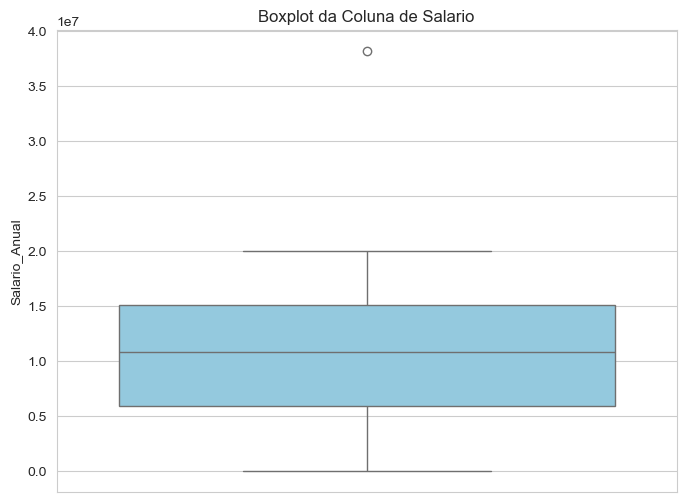

In [44]:
# É uma função da biblioteca Seaborn que define o estilo estético dos gráficos produzidos por Seaborn. Neste caso, 'whitegrid' é um dos estilos disponíveis em Seaborn
sns.set_style('whitegrid')

# Plota o boxplot da coluna de salário
plt.figure(figsize=(8,6 ))
sns.boxplot(data=df, y='Salario_Anual', color='skyblue')
plt.title('Boxplot da Coluna de Salario')
plt.ylabel('Salario_Anual')
plt.show()

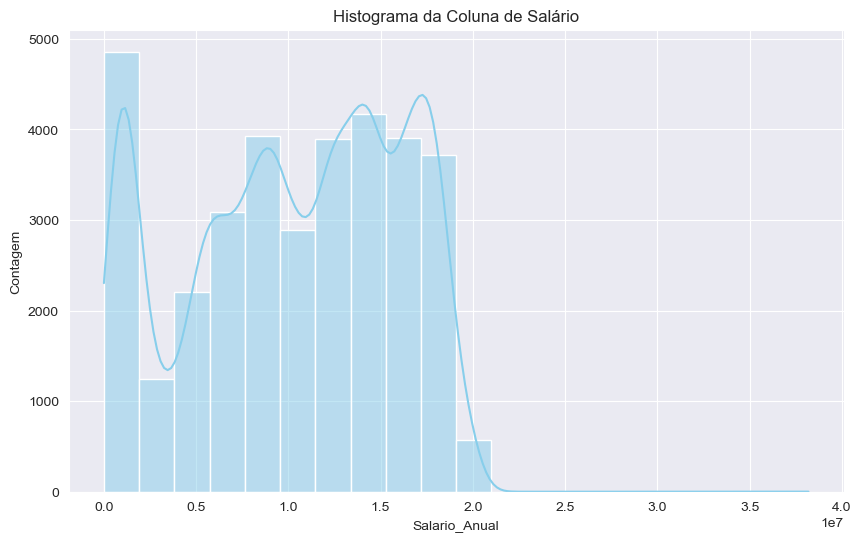

In [102]:
sns.set_style('darkgrid')

# Plotando um histograma dos salários para analisarmos a distribuição dos dados
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Salario_Anual', bins=20, kde=True, color='skyblue')
plt.title('Histograma da Coluna de Salário')
plt.xlabel('Salario_Anual')
plt.ylabel('Contagem')
plt.show()

Nós identificamos que existe um outlier nos daods de salário. Para temos uma mediana mais justa é interessante calcularmos ela sem esse outlier. (Na próxima auala aprenderemos a tratar outliers)

**Então vamos trazer a mediana dos salários removendo salários acima de 2 milhões.**

In [103]:
salarios_abaixo_2milhoes = df[df['Salario_Anual'] < 2000000]
salarios_abaixo_2milhoes['Salario_Anual'].median()

1011687.0

In [104]:
mediana_salario_abaixo_2milhoes = df[df['Salario_Anual'] < 2000000]['Salario_Anual'].median()
# Substitui os valores faltantes na coluna de salário pela mediana
df['Salario_Anual'].fillna(mediana_salario_abaixo_2milhoes, inplace=True)

C:\Users\marcelo\AppData\Local\Temp\ipykernel_40332\1164899669.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Salario_Anual'].fillna(mediana_salario_abaixo_2milhoes, inplace=True)


In [52]:
df['Salario_Anual'].isnull().sum()

np.int64(0)

In [53]:
df['Salario_Anual'].median()

1011687.0

Vemos que a mediana cai um pouco sem a presença do outlier. Então substituiremos os dados falantes pelo valor da mediana sem os outliers.

Caso não houvesse outlier, poderiamos substituir diretamente pela mediana.

**IMPORTANTE**

A nível de metodologia aprendemos primeiro a identificar e substituir dados faltantes e depois aprenderemos mais sobre o que fazer com dados que são outliers.

PORÉM algumas vezes em projetos de ciência de dados do dia dia essa ordem pode ser invertida, se nossa base tem muitos outliers é interessantes começarmos por eles, mas não é o caso desse problema.

**4) CHURN:**

**O  QUE ACONTECERIA SE SUSBSTITUIRMOS OS DADOS DA COLUNA QUE SERÁ A PREDITORA EM UM MODELO?**

- Imagine se na base de dados, 50% das pessoas desse churn e 50% não. Como faríamos para escolher das pessoas falantes quais são chur e quais não são? A chance de errar seria sempre de 50%;

- Agora imagine que 95% dos clientes **não realizaram churn.** Por uma questão obvia você diria para substituir os dados faltantes por não churn pois teríamos **95% chances de acertar?**

  PORÉM e se por um acaso nossas linhas faltantes tem um padrão e representassem os únicos registros que temos por exemplo de churn e não churn no país França? Noso modelo ficaria enviesado a achar que 100% dos casos da França seriam **NÃO CHURN**.



Como podemos ver são muitas variáveis pra se pensar e Ciência de Dados é isso! Como representam apenas 0.08% dos nosso dados eu indicaria para excluírmos as linhas sem registro PORÉM no dia dia iremos nos deparar com cenários onde o volume é maior, então vamos analisar juntos se a nossa decisão é a mais certa! 

<Axes: xlabel='Churn', ylabel='Count'>

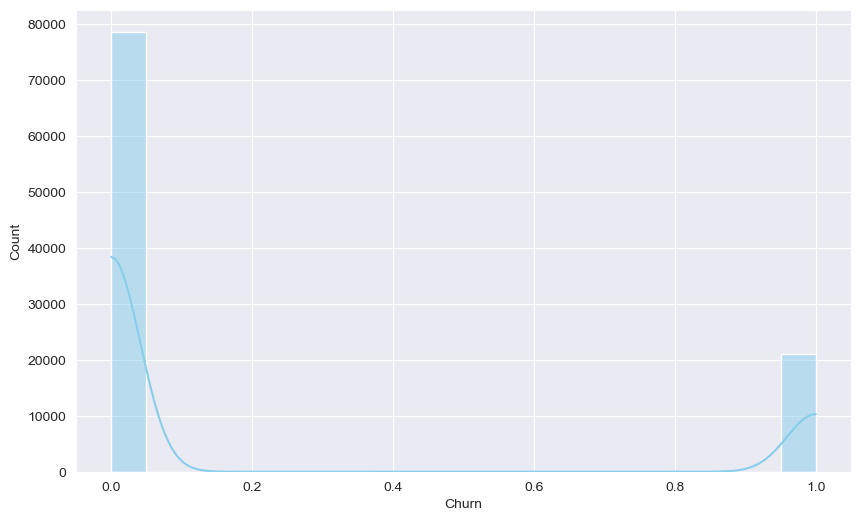

In [56]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Churn', bins=20, kde=True, color='skyblue')

Lembra que não transformamos ainda o dataframe original em Inteiro essa coluna? Por isso temos os pontos decimais nio gráfico.

Fica evidente que temos muitos mais casos de Não Churn que seria 0 do que Churn que seria 1.

In [105]:
df['Churn'].value_counts(normalize=True) * 100

Churn
0.0    78.854254
1.0    21.145746
Name: proportion, dtype: float64

In [ ]:
Agora vamos descobrir se achamos algum padrão de repetição nos dados faltantes.

In [106]:
# Explicando o código abaixo: 
#df --> DataFrame, 
#df['Churn'] --> Seleciona a coluna Churn
#.isnull() --> Verifica quais valores são nulos(vazios)

#Ou seja, o código irá retornar todas as linhas onde o Churn está vazio(NaN)

df[df['Churn'].isnull()]

,CustomerId,Sobrenome,Credit_Score,Pais,Genero,Idade,Tempo_Credito,Balance,Qtd_Produtos,Possui_Cartao,Membro_Ativo,Salario_Anual,Churn
406,15576928,Walsh,604,Spain,Female,23.0,6,0.00,1,1.0,0.0,1011687.0,NaN
407,15766552,Rossi,640,Spain,Male,23.0,4,0.00,2,0.0,1.0,1011687.0,NaN
408,15674833,Onio,605,Spain,Male,23.0,5,181671.16,2,1.0,1.0,1011687.0,NaN
409,15683534,Boulger,712,Spain,Female,23.0,7,110805.42,2,0.0,1.0,1011687.0,NaN
410,15677955,Hs?eh,673,Spain,Female,23.0,1,0.00,2,1.0,1.0,1011687.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
60582,15798521,Ch'en,675,France,Male,33.0,2,0.00,2,1.0,0.0,1011687.0,NaN
60583,15706263,Onyemauchechukwu,711,France,Male,33.0,7,0.00,2,1.0,1.0,1011687.0,NaN
60584,15603319,Onyekachi,712,France,Male,33.0,4,0.00,2,1.0,0.0,1011687.0,NaN
60585,15677512,Nwora,696,France,Male,33.0,2,111432.14,1,1.0,0.0,1011687.0,NaN


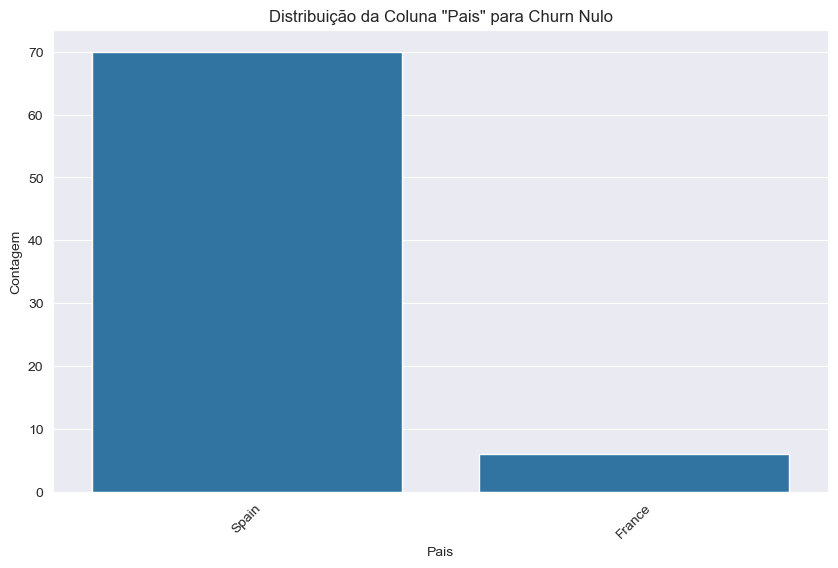

In [108]:
# Seleciona todas as linhas onde a coluna 'Churn' é nula
df_churn_nulo = df[df['Churn'].isnull()]

# Plotando a distribuição dos paises

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6)) # Cria uma tela para o grafico lde largura=10 e altura=6
sns.countplot(data=df_churn_nulo, x='Pais') #Conta quantas vezes cada país aparece, o data=df_churn_nulo mostra o DataFrame filtrado. Já o x=
plt.title('Distribuição da Coluna "Pais" para Churn Nulo')
plt.xlabel('Pais')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Explicando o código acima:
#plt.figure(figsize=(10, 6)) # Cria uma tela para o grafico lde largura=10 e altura=6
#sns.countplot(data=df_churn_nulo, x='Pais') #Conta quantas vezes cada país aparece, 
#o data=df_churn_nulo mostra o DataFrame filtrado. 
#Já o x='Pais'--> variável no eixo X
#plt.title('Distribuição da Coluna "Pais" para Churn Nulo')
#plt.xlabel('Pais')
#plt.ylabel('Contagem')
#plt.xticks(rotation=45)
#plt.show()


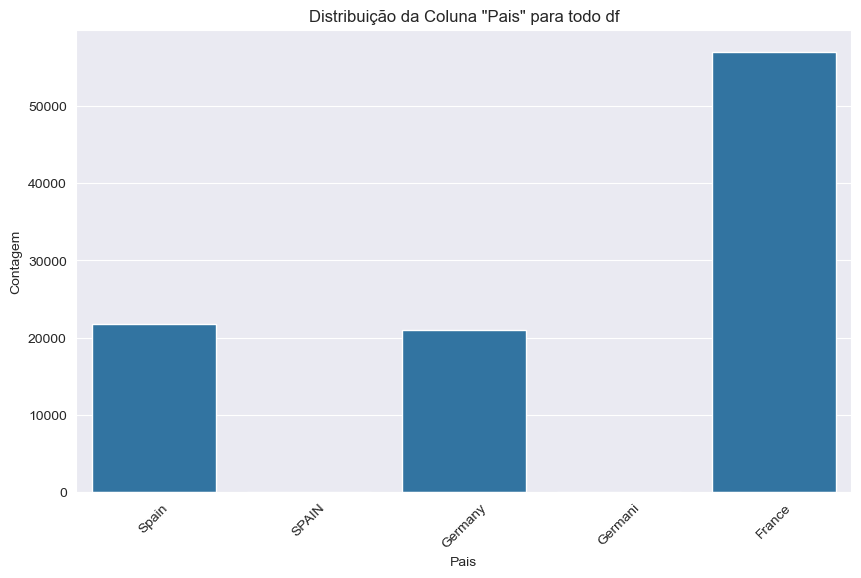

In [110]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Pais')
plt.title('Distribuição da Coluna "Pais" para todo df')
plt.xlabel('Pais')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.show()

# Alerta, vemos um vies maior para paises da Spain # 


Também vemos no gráfico acima os nomes dos países duplicados, isso ocorre porque na base de dados os nomes dos países não estão padronizados. Iremos tratá-los posteriormente.

In [ ]:
Em relação ao vies, vamos optar por remover as linahs nulas para evitar vies no modelo!

In [111]:
df.dropna(subset=['Churn'], inplace=True)

In [112]:
df['Churn'].isnull().sum()

np.int64(0)

In [114]:
df.isnull().sum()

CustomerId       0
Sobrenome        0
Credit_Score     0
Pais             0
Genero           0
Idade            0
Tempo_Credito    0
Balance          0
Qtd_Produtos     0
Possui_Cartao    0
Membro_Ativo     0
Salario_Anual    0
Churn            0
dtype: int64

In [ ]:
E agora sim podemos transformar essa coluna em inteiro!

In [115]:
df['Churn'] = df['Churn'].astype(int)

**MODULO 14 - AULA 4**

Outros tipos de Tratamento

Ouro ponto interessatne é mantermos os nomes das colunas de forma padronizada, por exemplo, quase todas nossas colunas tem nome em portugueês porém a coluna balance está em inglês. É interessante padronizarmos.

In [116]:
#Para isso usamos a função rename:
df.rename(columns={'Balance':'Balanco'}, inplace=True)

In [129]:
df.head() # Mostra a primeira linha do DataFrame

,Credit_Score,Pais,Genero,Idade,Tempo_Credito,Balanco,Qtd_Produtos,Possui_Cartao,Membro_Ativo,Salario_Anual,Churn
0,677,SPAIN,Male,18.0,5,134796.87,2,1.0,0.0,1011687.0,0
1,644,SPAIN,Female,18.0,7,0.00,1,0.0,1.0,1011687.0,0
2,641,SPAIN,Male,18.0,1,0.00,2,0.0,1.0,1011687.0,0
3,826,SPAIN,Male,18.0,2,0.00,2,0.0,1.0,1011687.0,0
4,774,SPAIN,Female,18.0,1,185891.54,1,1.0,0.0,1011687.0,0


Verificando se as colunas do dataframe possuem acentuação ou letras maiúsculas.

In [118]:
df['Pais'].unique()

array(['Spain', 'SPAIN', 'Germany', 'Germani', 'France'], dtype=object)

Aqui encontramos 2 problemas que exigem tratamento de dados:
- Para Spain temos tanto valor totalmente em caixa alta quanto valores com a preimeira letra em caixa alta.
- Para Germany temos valores escritos de forma errada, com i

In [123]:
# Para transformar todos os dados da coluna pais em caixa baixa:
df['Pais'] = df['Pais'].str.upper()
df['Pais'].unique()

array(['SPAIN', 'GERMANY', 'GERMANI', 'FRANCE'], dtype=object)

Agora vamos fazer a substituição dos valores errados na coluna país.

In [124]:
# Para isso usaremos a função replace
df['Pais'] = df['Pais'].replace('GERMANI','GERMANY')

In [125]:
df['Pais'].unique()

array(['SPAIN', 'GERMANY', 'FRANCE'], dtype=object)

Agora vamos verificar se nossos outros dados categóricos estão com alguma inconsistência:

In [126]:
df['Genero'].unique()

array(['Male', 'Female'], dtype=object)

Porque também não foi checado a coluna Sobrenome? BOm, nome acaba sendo um dado snsível e pense, em uma base com tantos dados, não será importante. Para nós a coluna de nomes e sobrenomes, podemos excluí-las da dase.

**É muito importante que antes de avançarem em projetos vocês removam todas colunas que não serão importantes!**

In [127]:
df.drop(columns=['Sobrenome'], inplace=True)

In [128]:
df.drop(columns=['CustomerId'], inplace=True)